# **Importing all the Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# **Defining the Location**

In [2]:
LATITUDE = 32.1877
LONGITUDE = 74.1945

START_DATE = "2024-01-01"
END_DATE = "2026-07-31"

TIMEZONE = "Asia/Karachi"

# **Fetching & Storing Weather Data**

In [3]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "surface_pressure",
        "precipitation",
        "cloud_cover"
    ]),
    "timezone": TIMEZONE
}

response = requests.get(weather_url, params=weather_params)

print(response.status_code)

weather_data = response.json()

weather_data.keys()


200


dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [4]:
weather_df = pd.DataFrame(weather_data["hourly"])


In [5]:
weather_df.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
0,2024-01-01T00:00,7.4,100,7.1,991.7,0.0,99
1,2024-01-01T01:00,7.0,98,2.8,991.7,0.0,100
2,2024-01-01T02:00,7.0,100,2.7,991.6,0.0,100
3,2024-01-01T03:00,7.1,99,2.5,991.7,0.0,100
4,2024-01-01T04:00,7.1,98,1.8,991.4,0.0,100


In [6]:
weather_df.describe()

,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
count,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353
std,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243
min,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000
25%,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000
50%,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000
75%,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000
max,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000


In [7]:
weather_df.shape

(22632, 7)

In [8]:
weather_df.tail(10)

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover
22622,2026-07-31T14:00,27.6,90,9.7,975.2,1.1,98
22623,2026-07-31T15:00,28.7,87,7.2,974.4,0.2,100
22624,2026-07-31T16:00,29.4,83,8.0,974.0,0.1,99
22625,2026-07-31T17:00,30.4,75,10.9,973.8,0.1,98
22626,2026-07-31T18:00,29.9,79,9.2,973.7,0.1,99
22627,2026-07-31T19:00,29.2,81,10.0,973.8,0.0,98
22628,2026-07-31T20:00,28.7,82,8.5,974.4,0.0,93
22629,2026-07-31T21:00,28.4,83,7.1,974.8,0.0,94
22630,2026-07-31T22:00,28.2,83,7.1,975.2,0.0,48
22631,2026-07-31T23:00,28.3,82,7.6,975.4,0.0,66


In [9]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  22632 non-null  object 
 1   temperature_2m        22632 non-null  float64
 2   relative_humidity_2m  22632 non-null  int64  
 3   wind_speed_10m        22632 non-null  float64
 4   surface_pressure      22632 non-null  float64
 5   precipitation         22632 non-null  float64
 6   cloud_cover           22632 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 1.2+ MB


# **Fetching & Storing Air Quality Data**

In [10]:
aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"

aq_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "hourly": ",".join([
        "pm10",
        "pm2_5",
        "carbon_monoxide",
        "nitrogen_dioxide",
        "sulphur_dioxide",
        "ozone",
        "us_aqi"
    ]),
    "timezone": TIMEZONE
}

response = requests.get(aq_url, params=aq_params)
print(response.status_code)

aq_data = response.json()

aq_df = pd.DataFrame(aq_data["hourly"])

200


In [11]:
aq_data.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [12]:
aq_df.head(10)

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01T00:00,330.6,231.0,3325.0,57.2,31.0,39.0,242
1,2024-01-01T01:00,330.6,230.5,3166.0,47.2,23.6,44.0,243
2,2024-01-01T02:00,295.2,205.8,2997.0,37.6,17.0,49.0,244
3,2024-01-01T03:00,266.4,186.3,2823.0,29.1,12.1,54.0,244
4,2024-01-01T04:00,254.3,177.4,2641.0,21.1,7.9,60.0,244
5,2024-01-01T05:00,224.4,156.5,2096.0,11.0,8.6,74.0,244
6,2024-01-01T06:00,219.3,153.2,2115.0,11.9,7.2,72.0,245
7,2024-01-01T07:00,221.2,154.6,2140.0,13.2,5.2,71.0,245
8,2024-01-01T08:00,223.5,156.0,2151.0,14.0,3.7,74.0,246
9,2024-01-01T09:00,223.5,156.0,2139.0,13.9,2.8,84.0,246


In [13]:
weather_df["time"] = pd.to_datetime(weather_df["time"])
aq_df["time"] = pd.to_datetime(aq_df["time"])

# **Merging both Data sets**

In [14]:
df = pd.merge(
    weather_df,
    aq_df,
    on="time",
    how="inner")
df.head(10)

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01 00:00:00,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242
1,2024-01-01 01:00:00,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243
2,2024-01-01 02:00:00,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244
3,2024-01-01 03:00:00,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244
4,2024-01-01 04:00:00,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244
5,2024-01-01 05:00:00,7.0,98,2.8,991.3,0.0,100,224.4,156.5,2096.0,11.0,8.6,74.0,244
6,2024-01-01 06:00:00,7.9,98,2.3,992.0,0.0,100,219.3,153.2,2115.0,11.9,7.2,72.0,245
7,2024-01-01 07:00:00,8.4,98,2.6,992.6,0.0,100,221.2,154.6,2140.0,13.2,5.2,71.0,245
8,2024-01-01 08:00:00,8.8,99,2.6,993.1,0.0,100,223.5,156.0,2151.0,14.0,3.7,74.0,246
9,2024-01-01 09:00:00,9.4,98,2.9,993.6,0.0,100,223.5,156.0,2139.0,13.9,2.8,84.0,246


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  22632 non-null  datetime64[ns]
 1   temperature_2m        22632 non-null  float64       
 2   relative_humidity_2m  22632 non-null  int64         
 3   wind_speed_10m        22632 non-null  float64       
 4   surface_pressure      22632 non-null  float64       
 5   precipitation         22632 non-null  float64       
 6   cloud_cover           22632 non-null  int64         
 7   pm10                  22632 non-null  float64       
 8   pm2_5                 22632 non-null  float64       
 9   carbon_monoxide       22632 non-null  float64       
 10  nitrogen_dioxide      22632 non-null  float64       
 11  sulphur_dioxide       22632 non-null  float64       
 12  ozone                 22632 non-null  float64       
 13  us_aqi          

In [16]:
df.shape

(22632, 14)

# **EDA - Exploratory Data Analysis**

In [17]:
df.isnull().sum()

,0
time,0
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
surface_pressure,0
precipitation,0
cloud_cover,0
pm10,0
pm2_5,0
carbon_monoxide,0


In [18]:
df.describe()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,22632,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,2025-04-16 11:29:59.999999744,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353,90.654436,63.776277,722.434738,20.712853,13.518213,96.358475,143.816322
min,2024-01-01 00:00:00,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000,3.100000,2.200000,120.000000,0.000000,0.000000,0.000000,57.000000
25%,2024-08-23 17:45:00,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000,48.100000,31.900000,357.000000,6.900000,8.200000,52.000000,105.000000
50%,2025-04-16 11:30:00,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000,72.200000,48.300000,524.000000,15.200000,11.700000,87.000000,144.000000
75%,2025-12-08 05:15:00,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000,113.400000,77.500000,860.000000,29.000000,16.500000,140.000000,169.000000
max,2026-07-31 23:00:00,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000,763.700000,348.300000,3837.000000,130.400000,75.500000,255.000000,355.000000
std,NaN,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243,63.947166,48.047906,558.829893,18.378782,7.934291,54.020336,47.035265


In [19]:
df.drop(columns=["time"]).describe()

,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,23.616989,63.666976,7.146072,982.187831,0.090116,33.250353,90.654436,63.776277,722.434738,20.712853,13.518213,96.358475,143.816322
std,8.848786,23.246150,4.102802,6.967652,0.651678,40.908243,63.947166,48.047906,558.829893,18.378782,7.934291,54.020336,47.035265
min,2.600000,7.000000,0.000000,964.700000,0.000000,0.000000,3.100000,2.200000,120.000000,0.000000,0.000000,0.000000,57.000000
25%,16.700000,46.000000,4.200000,976.400000,0.000000,0.000000,48.100000,31.900000,357.000000,6.900000,8.200000,52.000000,105.000000
50%,25.100000,66.000000,6.600000,982.300000,0.000000,8.000000,72.200000,48.300000,524.000000,15.200000,11.700000,87.000000,144.000000
75%,30.200000,84.000000,9.500000,988.000000,0.000000,80.000000,113.400000,77.500000,860.000000,29.000000,16.500000,140.000000,169.000000
max,45.500000,100.000000,36.300000,1001.200000,32.500000,100.000000,763.700000,348.300000,3837.000000,130.400000,75.500000,255.000000,355.000000


# **Data Visualization **

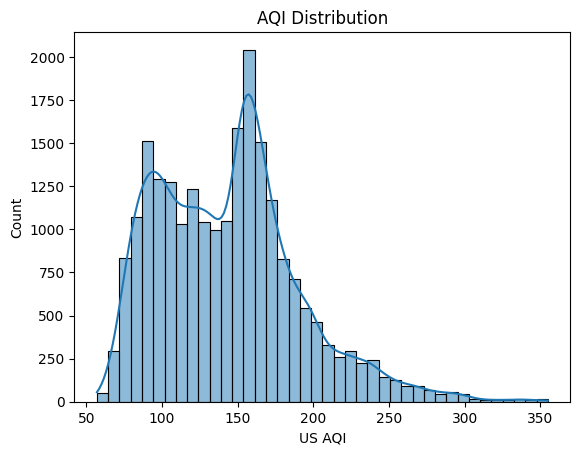

In [20]:
sns.histplot(df["us_aqi"], bins=40, kde=True)

plt.title("AQI Distribution")
plt.xlabel("US AQI")
plt.show()

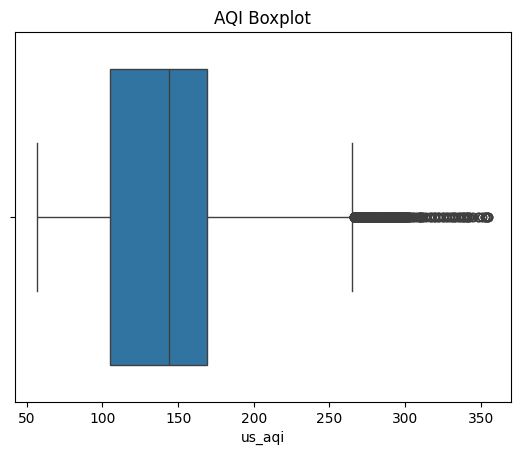

In [21]:
sns.boxplot(x=df["us_aqi"])

plt.title("AQI Boxplot")
plt.show()

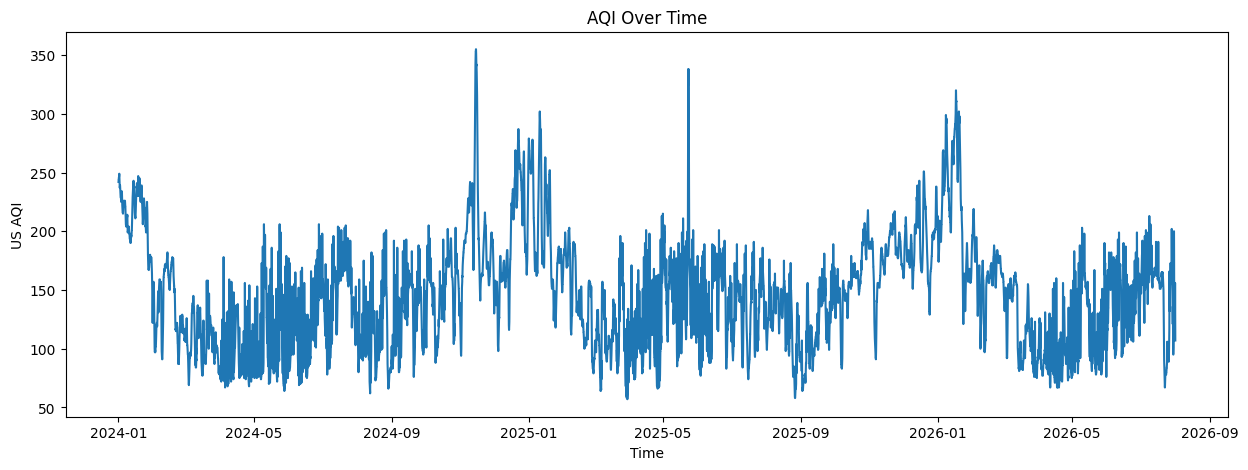

In [22]:
plt.figure(figsize=(15, 5))

plt.plot(df["time"], df["us_aqi"])

plt.title("AQI Over Time")
plt.xlabel("Time")
plt.ylabel("US AQI")

plt.show()

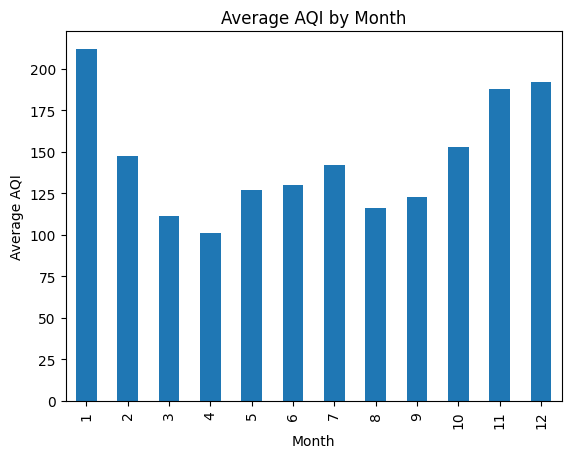

In [23]:
df["month"] = df["time"].dt.month

monthly_aqi = df.groupby("month")["us_aqi"].mean()

monthly_aqi.plot(kind="bar")

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

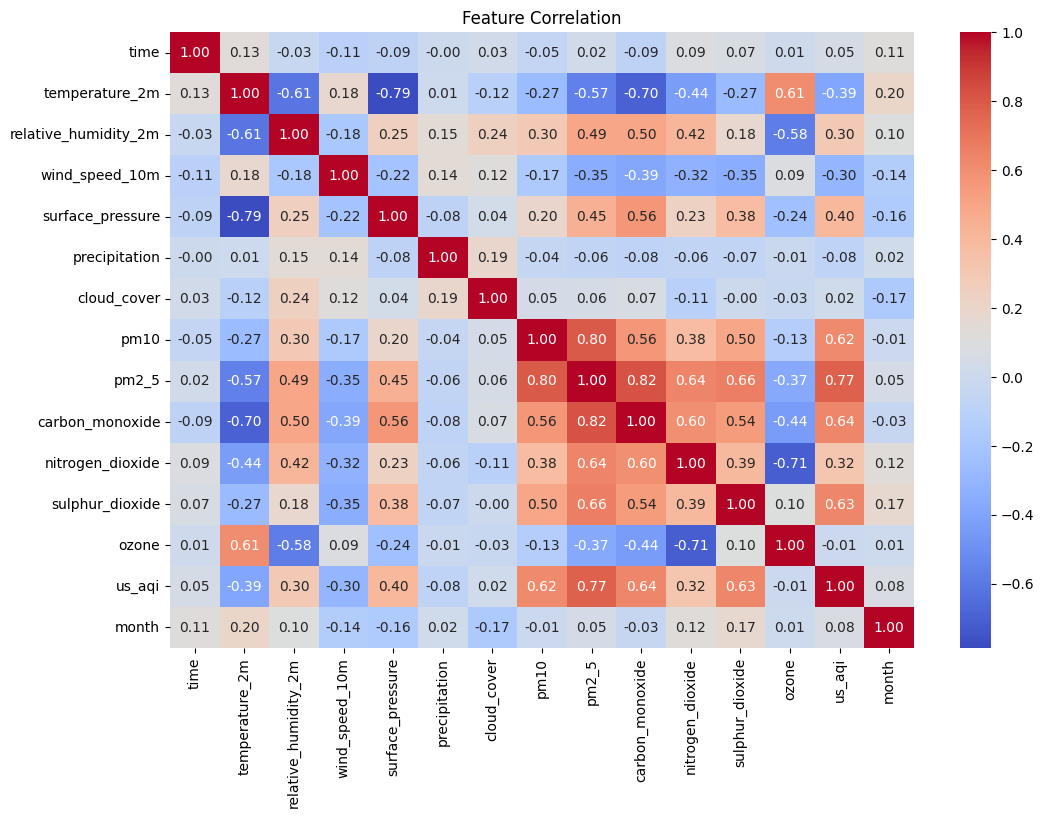

In [24]:
corr = df.corr()
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [25]:
corr["us_aqi"].sort_values(ascending=False)

,us_aqi
us_aqi,1.000000
pm2_5,0.771059
carbon_monoxide,0.636397
sulphur_dioxide,0.631165
pm10,0.621284
surface_pressure,0.402725
nitrogen_dioxide,0.321497
relative_humidity_2m,0.295171
month,0.075511
time,0.051356


# **Feature Engineering**

**Formating Time**

In [26]:
df["hour"] = df["time"].dt.hour
df.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,month,hour
0,2024-01-01 00:00:00,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242,1,0
1,2024-01-01 01:00:00,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243,1,1
2,2024-01-01 02:00:00,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244,1,2
3,2024-01-01 03:00:00,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244,1,3
4,2024-01-01 04:00:00,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244,1,4


In [27]:
df["day_of_week"] = df["time"].dt.day_of_week
df.head(25)

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,month,hour,day_of_week
0,2024-01-01 00:00:00,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242,1,0,0
1,2024-01-01 01:00:00,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243,1,1,0
2,2024-01-01 02:00:00,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244,1,2,0
3,2024-01-01 03:00:00,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244,1,3,0
4,2024-01-01 04:00:00,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244,1,4,0
5,2024-01-01 05:00:00,7.0,98,2.8,991.3,0.0,100,224.4,156.5,2096.0,11.0,8.6,74.0,244,1,5,0
6,2024-01-01 06:00:00,7.9,98,2.3,992.0,0.0,100,219.3,153.2,2115.0,11.9,7.2,72.0,245,1,6,0
7,2024-01-01 07:00:00,8.4,98,2.6,992.6,0.0,100,221.2,154.6,2140.0,13.2,5.2,71.0,245,1,7,0
8,2024-01-01 08:00:00,8.8,99,2.6,993.1,0.0,100,223.5,156.0,2151.0,14.0,3.7,74.0,246,1,8,0
9,2024-01-01 09:00:00,9.4,98,2.9,993.6,0.0,100,223.5,156.0,2139.0,13.9,2.8,84.0,246,1,9,0


In [28]:
df["month"] = df["time"].dt.month
df

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,month,hour,day_of_week
0,2024-01-01 00:00:00,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242,1,0,0
1,2024-01-01 01:00:00,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243,1,1,0
2,2024-01-01 02:00:00,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244,1,2,0
3,2024-01-01 03:00:00,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244,1,3,0
4,2024-01-01 04:00:00,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22627,2026-07-31 19:00:00,29.2,81,10.0,973.8,0.0,98,29.7,29.5,455.0,13.9,7.3,93.0,151,7,19,4
22628,2026-07-31 20:00:00,28.7,82,8.5,974.4,0.0,93,29.6,29.2,509.0,16.9,7.1,74.0,135,7,20,4
22629,2026-07-31 21:00:00,28.4,83,7.1,974.8,0.0,94,28.1,27.6,525.0,18.6,6.8,62.0,113,7,21,4
22630,2026-07-31 22:00:00,28.2,83,7.1,975.2,0.0,48,28.2,27.6,520.0,19.8,6.5,53.0,110,7,22,4


In [29]:
new_order = [
    # Time features
    "time",
    "month",
    "day_of_week",
    "hour",
    # Weather features
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "surface_pressure",
    "precipitation",
    "cloud_cover",
    # Pollutant features
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    # Target
    "us_aqi",
]

df = df[new_order]
df

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22627,2026-07-31 19:00:00,7,4,19,29.2,81,10.0,973.8,0.0,98,29.7,29.5,455.0,13.9,7.3,93.0,151
22628,2026-07-31 20:00:00,7,4,20,28.7,82,8.5,974.4,0.0,93,29.6,29.2,509.0,16.9,7.1,74.0,135
22629,2026-07-31 21:00:00,7,4,21,28.4,83,7.1,974.8,0.0,94,28.1,27.6,525.0,18.6,6.8,62.0,113
22630,2026-07-31 22:00:00,7,4,22,28.2,83,7.1,975.2,0.0,48,28.2,27.6,520.0,19.8,6.5,53.0,110


**Lag Features**

In [30]:
df["aqi_lag_1"] = df["us_aqi"].shift(1)

/tmp/ipykernel_1227/244510405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aqi_lag_1"] = df["us_aqi"].shift(1)


In [31]:
df.head()

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,aqi_lag_1
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242,NaN
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243,242.0
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244,243.0
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244,244.0
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244,244.0


In [32]:
df["aqi_lag_12"] = df["us_aqi"].shift(12)
df["aqi_lag_24"] = df["us_aqi"].shift(24)

/tmp/ipykernel_1227/3537190622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aqi_lag_12"] = df["us_aqi"].shift(12)
/tmp/ipykernel_1227/3537190622.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aqi_lag_24"] = df["us_aqi"].shift(24)


In [33]:
df.head()

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,aqi_lag_1,aqi_lag_12,aqi_lag_24
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,330.6,231.0,3325.0,57.2,31.0,39.0,242,NaN,NaN,NaN
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,330.6,230.5,3166.0,47.2,23.6,44.0,243,242.0,NaN,NaN
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,295.2,205.8,2997.0,37.6,17.0,49.0,244,243.0,NaN,NaN
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,266.4,186.3,2823.0,29.1,12.1,54.0,244,244.0,NaN,NaN
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,254.3,177.4,2641.0,21.1,7.9,60.0,244,244.0,NaN,NaN


**Rolling Average**

In [34]:
df["aqi_rolling_6"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(6)
    .mean()
)

/tmp/ipykernel_1227/550777890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["aqi_rolling_6"] = (


In [35]:
df.head(10)

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,...,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,aqi_lag_1,aqi_lag_12,aqi_lag_24,aqi_rolling_6
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,...,231.0,3325.0,57.2,31.0,39.0,242,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,...,230.5,3166.0,47.2,23.6,44.0,243,242.0,NaN,NaN,NaN
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,...,205.8,2997.0,37.6,17.0,49.0,244,243.0,NaN,NaN,NaN
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,...,186.3,2823.0,29.1,12.1,54.0,244,244.0,NaN,NaN,NaN
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,...,177.4,2641.0,21.1,7.9,60.0,244,244.0,NaN,NaN,NaN
5,2024-01-01 05:00:00,1,0,5,7.0,98,2.8,991.3,0.0,100,...,156.5,2096.0,11.0,8.6,74.0,244,244.0,NaN,NaN,NaN
6,2024-01-01 06:00:00,1,0,6,7.9,98,2.3,992.0,0.0,100,...,153.2,2115.0,11.9,7.2,72.0,245,244.0,NaN,NaN,243.500000
7,2024-01-01 07:00:00,1,0,7,8.4,98,2.6,992.6,0.0,100,...,154.6,2140.0,13.2,5.2,71.0,245,245.0,NaN,NaN,244.000000
8,2024-01-01 08:00:00,1,0,8,8.8,99,2.6,993.1,0.0,100,...,156.0,2151.0,14.0,3.7,74.0,246,245.0,NaN,NaN,244.333333
9,2024-01-01 09:00:00,1,0,9,9.4,98,2.9,993.6,0.0,100,...,156.0,2139.0,13.9,2.8,84.0,246,246.0,NaN,NaN,244.666667


# **Defining What We Want To Predict**

In [36]:
df["target_aqi"] = df["us_aqi"].shift(-24)

/tmp/ipykernel_1227/1513741352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_aqi"] = df["us_aqi"].shift(-24)


In [37]:
df

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,...,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,aqi_lag_1,aqi_lag_12,aqi_lag_24,aqi_rolling_6,target_aqi
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,...,3325.0,57.2,31.0,39.0,242,NaN,NaN,NaN,NaN,241.0
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,...,3166.0,47.2,23.6,44.0,243,242.0,NaN,NaN,NaN,239.0
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,...,2997.0,37.6,17.0,49.0,244,243.0,NaN,NaN,NaN,238.0
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,...,2823.0,29.1,12.1,54.0,244,244.0,NaN,NaN,NaN,237.0
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,...,2641.0,21.1,7.9,60.0,244,244.0,NaN,NaN,NaN,238.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22627,2026-07-31 19:00:00,7,4,19,29.2,81,10.0,973.8,0.0,98,...,455.0,13.9,7.3,93.0,151,156.0,137.0,200.0,138.333333,NaN
22628,2026-07-31 20:00:00,7,4,20,28.7,82,8.5,974.4,0.0,93,...,509.0,16.9,7.1,74.0,135,151.0,136.0,193.0,142.333333,NaN
22629,2026-07-31 21:00:00,7,4,21,28.4,83,7.1,974.8,0.0,94,...,525.0,18.6,6.8,62.0,113,135.0,134.0,179.0,144.000000,NaN
22630,2026-07-31 22:00:00,7,4,22,28.2,83,7.1,975.2,0.0,48,...,520.0,19.8,6.5,53.0,110,113.0,132.0,160.0,142.000000,NaN


# **Feature Selection**

In [38]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "surface_pressure",
    "pm2_5",
    "pm10",
    "hour",
    "day_of_week",
    "month",
    "aqi_lag_1",
    "aqi_lag_12",
    "aqi_lag_24",
    "aqi_rolling_6"
]

target = "target_aqi"


# **Removing Missing Rows**

In [39]:
model_df = df[features + [target]].dropna().reset_index(drop=True)
model_df

,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,pm2_5,pm10,hour,day_of_week,month,aqi_lag_1,aqi_lag_12,aqi_lag_24,aqi_rolling_6,target_aqi
0,6.0,99,9.5,991.0,193.7,278.5,0,1,1,242.0,247.0,242.0,245.333333,229.0
1,5.7,100,9.4,990.6,195.6,281.3,1,1,1,241.0,247.0,243.0,244.166667,229.0
2,5.2,100,9.4,990.4,193.2,278.5,2,1,1,239.0,247.0,244.0,242.833333,229.0
3,5.3,100,7.9,990.2,190.0,272.9,3,1,1,238.0,248.0,244.0,241.500000,229.0
4,6.2,100,2.4,990.1,182.5,262.6,4,1,1,237.0,248.0,244.0,240.166667,228.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22579,30.3,82,8.8,972.4,55.8,65.7,19,3,7,200.0,97.0,136.0,158.833333,151.0
22580,29.8,85,6.7,972.9,53.8,60.8,20,3,7,200.0,99.0,131.0,173.666667,135.0
22581,29.4,86,7.9,973.4,57.2,62.4,21,3,7,193.0,101.0,118.0,185.833333,113.0
22582,29.1,85,10.5,973.7,61.0,65.4,22,3,7,179.0,104.0,99.0,190.000000,110.0


In [40]:
model_df.shape

(22584, 14)

In [41]:
model_df.isnull().sum()

,0
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
surface_pressure,0
pm2_5,0
pm10,0
hour,0
day_of_week,0
month,0
aqi_lag_1,0


# **Splitting Training & Testing Data**

In [42]:
split_index = int(len(model_df) * 0.8)

train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# **Training Model (Random Forest)**

In [43]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# **Prediction & Metric Analysis**

In [44]:
predictions = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 16.094401151206554


In [46]:
rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("RMSE:", rmse)

RMSE: 20.91454562516495


In [47]:
r2 = r2_score(y_test, predictions)

print("R²:", r2)

R²: 0.647658381745357


# **Visualizing Predictions**

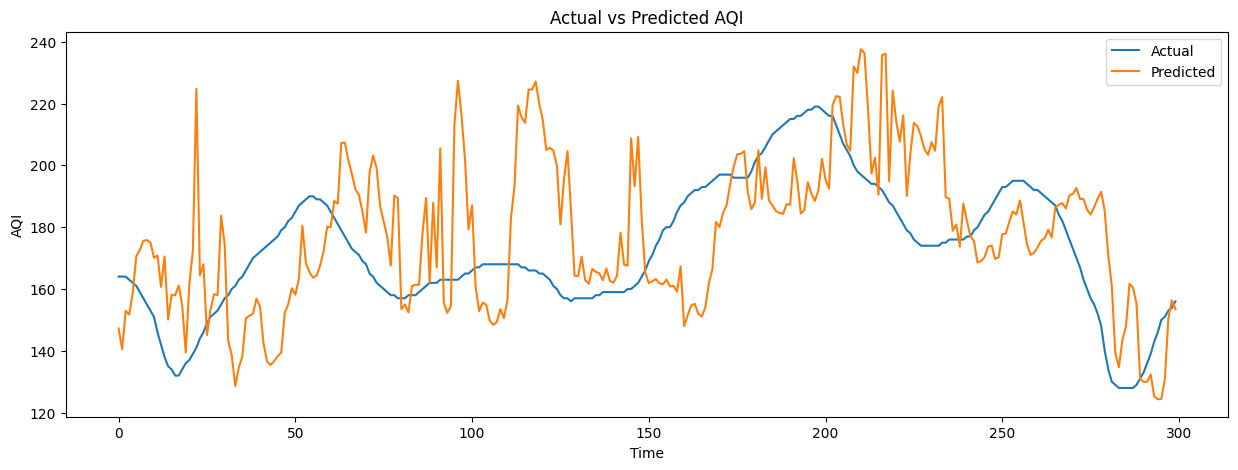

In [48]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(predictions[:300], label="Predicted")

plt.title("Actual vs Predicted AQI")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()

plt.show()

# **Day 2 & Day 3 Predictions**

In [49]:
df["target_aqi_48"] = df["us_aqi"].shift(-48)
model_df_48 = df[features + ["target_aqi_48"]].dropna()

split_index_48 = int(len(model_df_48) * 0.8)

train_48 = model_df_48.iloc[:split_index_48]
test_48 = model_df_48.iloc[split_index_48:]

X_train_48 = train_48[features]
y_train_48 = train_48["target_aqi_48"]

X_test_48 = test_48[features]
y_test_48 = test_48["target_aqi_48"]

model_48 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_48.fit(X_train_48, y_train_48)
predictions_48 = model_48.predict(X_test_48)

mae_48 = mean_absolute_error(y_test_48, predictions_48)

rmse_48 = np.sqrt(
    mean_squared_error(y_test_48, predictions_48)
)

r2_48 = r2_score(y_test_48, predictions_48)

print("48-Hour Prediction")
print("MAE:", mae_48)
print("RMSE:", rmse_48)
print("R²:", r2_48)

/tmp/ipykernel_1227/3521040485.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_aqi_48"] = df["us_aqi"].shift(-48)


48-Hour Prediction
MAE: 21.775086436170213
RMSE: 26.685659378535103
R²: 0.4264749015391601


In [50]:
df["target_aqi_72"] = df["us_aqi"].shift(-72)
model_df_72 = df[features + ["target_aqi_72"]].dropna()

split_index_72 = int(len(model_df_72) * 0.8)

train_72 = model_df_72.iloc[:split_index_72]
test_72 = model_df_72.iloc[split_index_72:]

X_train_72 = train_72[features]
y_train_72 = train_72["target_aqi_72"]

X_test_72 = test_72[features]
y_test_72 = test_72["target_aqi_72"]

model_72 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_72.fit(X_train_72, y_train_72)

predictions_72 = model_72.predict(X_test_72)

mae_72 = mean_absolute_error(y_test_72, predictions_72)

rmse_72 = np.sqrt(
    mean_squared_error(y_test_72, predictions_72)
)

r2_72 = r2_score(y_test_72, predictions_72)

print("72-Hour Prediction")
print("MAE:", mae_72)
print("RMSE:", rmse_72)
print("R²:", r2_72)

/tmp/ipykernel_1227/2702071355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_aqi_72"] = df["us_aqi"].shift(-72)


72-Hour Prediction
MAE: 24.481794587400177
RMSE: 30.25506213226688
R²: 0.2630500576821013


# **XGBoost On The Same Dataset**

In [51]:
!pip install xgboost

In [52]:
from xgboost import XGBRegressor
model_xgb_24 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb_24.fit(X_train, y_train)

predictions_xgb_24 = model_xgb_24.predict(X_test)

mae_xgb_24 = mean_absolute_error(y_test, predictions_xgb_24)

rmse_xgb_24 = np.sqrt(
    mean_squared_error(y_test, predictions_xgb_24)
)

r2_xgb_24 = r2_score(y_test, predictions_xgb_24)

print("XGBoost - 24 Hours")
print("MAE:", mae_xgb_24)
print("RMSE:", rmse_xgb_24)
print("R²:", r2_xgb_24)

XGBoost - 24 Hours
MAE: 15.05534177167452
RMSE: 19.61788671150739
R²: 0.6899929849183246


In [53]:
model_xgb_48 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb_48.fit(X_train_48, y_train_48)

predictions_xgb_48 = model_xgb_48.predict(X_test_48)

mae_xgb_48 = mean_absolute_error(y_test_48, predictions_xgb_48)

rmse_xgb_48 = np.sqrt(
    mean_squared_error(y_test_48, predictions_xgb_48)
)

r2_xgb_48 = r2_score(y_test_48, predictions_xgb_48)

print("XGBoost - 48 Hours")
print("MAE:", mae_xgb_48)
print("RMSE:", rmse_xgb_48)
print("R²:", r2_xgb_48)

XGBoost - 48 Hours
MAE: 20.724908132079644
RMSE: 25.71863326213313
R²: 0.4672881927468915


In [54]:
model_xgb_72 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb_72.fit(X_train_72, y_train_72)

predictions_xgb_72 = model_xgb_72.predict(X_test_72)

mae_xgb_72 = mean_absolute_error(y_test_72, predictions_xgb_72)

rmse_xgb_72 = np.sqrt(
    mean_squared_error(y_test_72, predictions_xgb_72)
)

r2_xgb_72 = r2_score(y_test_72, predictions_xgb_72)

print("XGBoost - 72 Hours")
print("MAE:", mae_xgb_72)
print("RMSE:", rmse_xgb_72)
print("R²:", r2_xgb_72)

XGBoost - 72 Hours
MAE: 23.59573193324173
RMSE: 29.245816587678533
R²: 0.3113962317402389


# **Feature Tuning For Better Performance Metrics**

In [55]:
df = df.copy()

df["aqi_lag_3"] = df["us_aqi"].shift(3)
df["aqi_lag_6"] = df["us_aqi"].shift(6)
df["aqi_lag_12"] = df["us_aqi"].shift(12)
df["aqi_lag_48"] = df["us_aqi"].shift(48)

df["aqi_rolling_24"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(24)
    .mean()
)

In [56]:
df.head()

,time,month,day_of_week,hour,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,precipitation,cloud_cover,...,aqi_lag_12,aqi_lag_24,aqi_rolling_6,target_aqi,target_aqi_48,target_aqi_72,aqi_lag_3,aqi_lag_6,aqi_lag_48,aqi_rolling_24
0,2024-01-01 00:00:00,1,0,0,7.4,100,7.1,991.7,0.0,99,...,NaN,NaN,NaN,241.0,229.0,234.0,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,1,0,1,7.0,98,2.8,991.7,0.0,100,...,NaN,NaN,NaN,239.0,229.0,234.0,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,1,0,2,7.0,100,2.7,991.6,0.0,100,...,NaN,NaN,NaN,238.0,229.0,232.0,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,1,0,3,7.1,99,2.5,991.7,0.0,100,...,NaN,NaN,NaN,237.0,229.0,230.0,242.0,NaN,NaN,NaN
4,2024-01-01 04:00:00,1,0,4,7.1,98,1.8,991.4,0.0,100,...,NaN,NaN,NaN,238.0,228.0,228.0,243.0,NaN,NaN,NaN


In [57]:
features_v2 = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "surface_pressure",
    "pm2_5",
    "pm10",
    "hour",
    "day_of_week",
    "month",

    "aqi_lag_1",
    "aqi_lag_3",
    "aqi_lag_6",
    "aqi_lag_12",
    "aqi_lag_24",
    "aqi_lag_48",

    "aqi_rolling_6",
    "aqi_rolling_24"
]

In [58]:
XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [59]:
model_df_24_v2 = df[features_v2 + ["target_aqi"]].dropna()

split_24_v2 = int(len(model_df_24_v2) * 0.8)

train_24_v2 = model_df_24_v2.iloc[:split_24_v2]
test_24_v2 = model_df_24_v2.iloc[split_24_v2:]

X_train_24_v2 = train_24_v2[features_v2]
y_train_24_v2 = train_24_v2["target_aqi"]

X_test_24_v2 = test_24_v2[features_v2]
y_test_24_v2 = test_24_v2["target_aqi"]

model_xgb_24_v2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb_24_v2.fit(X_train_24_v2, y_train_24_v2)

predictions_24_v2 = model_xgb_24_v2.predict(X_test_24_v2)

mae_24_v2 = mean_absolute_error(y_test_24_v2, predictions_24_v2)
rmse_24_v2 = np.sqrt(mean_squared_error(y_test_24_v2, predictions_24_v2))
r2_24_v2 = r2_score(y_test_24_v2, predictions_24_v2)

print("XGBoost - 24 Hours (Experiment 2)")
print("MAE:", mae_24_v2)
print("RMSE:", rmse_24_v2)
print("R²:", r2_24_v2)

XGBoost - 24 Hours (Experiment 2)
MAE: 15.165807600562454
RMSE: 19.720276330207316
R²: 0.6867994298779365


In [60]:
model_df_48_v2 = df[features_v2 + ["target_aqi_48"]].dropna()

split_48_v2 = int(len(model_df_48_v2) * 0.8)

train_48_v2 = model_df_48_v2.iloc[:split_48_v2]
test_48_v2 = model_df_48_v2.iloc[split_48_v2:]

X_train_48_v2 = train_48_v2[features_v2]
y_train_48_v2 = train_48_v2["target_aqi_48"]

X_test_48_v2 = test_48_v2[features_v2]
y_test_48_v2 = test_48_v2["target_aqi_48"]

model_xgb_48_v2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_xgb_48_v2.fit(X_train_48_v2, y_train_48_v2)

predictions_48_v2 = model_xgb_48_v2.predict(X_test_48_v2)

mae_48_v2 = mean_absolute_error(y_test_48_v2, predictions_48_v2)
rmse_48_v2 = np.sqrt(mean_squared_error(y_test_48_v2, predictions_48_v2))
r2_48_v2 = r2_score(y_test_48_v2, predictions_48_v2)

print("XGBoost - 48 Hours (Experiment 2)")
print("MAE:", mae_48_v2)
print("RMSE:", rmse_48_v2)
print("R²:", r2_48_v2)

XGBoost - 48 Hours (Experiment 2)
MAE: 20.674772269342892
RMSE: 25.65819427450309
R²: 0.46997778932041034


# **Tuning XGBoost With Different Configurations**

In [61]:
from xgboost import XGBRegressor

models = {
    "Model 1": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "Model 2": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "Model 3": XGBRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=6,
        random_state=42
    ),

    "Model 4": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    "Model 5": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    ),

    "Model 6": XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R²
0,Model 1,15.055342,19.617887,0.689993
1,Model 2,15.126879,19.736004,0.686249
2,Model 3,15.211763,19.649182,0.689003
3,Model 4,15.263626,19.746121,0.685927
4,Model 5,15.335003,19.907543,0.680771
5,Model 6,15.325193,19.757270,0.685572


# **Trying CatBoost Algorithm**

In [62]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.8 MB/s eta 0:00:00


In [63]:
from catboost import CatBoostRegressor

model_df_24_cb = df[features + ["target_aqi"]].dropna()

split_24_cb = int(len(model_df_24_cb) * 0.8)

train_24_cb = model_df_24_cb.iloc[:split_24_cb]
test_24_cb = model_df_24_cb.iloc[split_24_cb:]

X_train_24_cb = train_24_cb[features]
y_train_24_cb = train_24_cb["target_aqi"]

X_test_24_cb = test_24_cb[features]
y_test_24_cb = test_24_cb["target_aqi"]

model_cb_24 = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

model_cb_24.fit(X_train_24_cb, y_train_24_cb)

predictions_cb_24 = model_cb_24.predict(X_test_24_cb)

mae_cb_24 = mean_absolute_error(y_test_24_cb, predictions_cb_24)
rmse_cb_24 = np.sqrt(mean_squared_error(y_test_24_cb, predictions_cb_24))
r2_cb_24 = r2_score(y_test_24_cb, predictions_cb_24)

print("CatBoost - 24 Hours")
print("MAE:", mae_cb_24)
print("RMSE:", rmse_cb_24)
print("R²:", r2_cb_24)

CatBoost - 24 Hours
MAE: 15.243026022916853
RMSE: 19.478679687668443
R²: 0.6943769475474337


In [64]:

model_df_48_cb = df[features + ["target_aqi_48"]].dropna()


split_48_cb = int(len(model_df_48_cb) * 0.8)

train_48_cb = model_df_48_cb.iloc[:split_48_cb]
test_48_cb = model_df_48_cb.iloc[split_48_cb:]

X_train_48_cb = train_48_cb[features]
y_train_48_cb = train_48_cb["target_aqi_48"]

X_test_48_cb = test_48_cb[features]
y_test_48_cb = test_48_cb["target_aqi_48"]

model_cb_48 = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

model_cb_48.fit(X_train_48_cb, y_train_48_cb)

predictions_cb_48 = model_cb_48.predict(X_test_48_cb)

mae_cb_48 = mean_absolute_error(y_test_48_cb, predictions_cb_48)
rmse_cb_48 = np.sqrt(mean_squared_error(y_test_48_cb, predictions_cb_48))
r2_cb_48 = r2_score(y_test_48_cb, predictions_cb_48)

print("CatBoost - 48 Hours")
print("MAE:", mae_cb_48)
print("RMSE:", rmse_cb_48)
print("R²:", r2_cb_48)

CatBoost - 48 Hours
MAE: 20.11940182012317
RMSE: 24.612960977777508
R²: 0.5121073474788664


In [65]:

model_df_72_cb = df[features + ["target_aqi_72"]].dropna()

split_72_cb = int(len(model_df_72_cb) * 0.8)

train_72_cb = model_df_72_cb.iloc[:split_72_cb]
test_72_cb = model_df_72_cb.iloc[split_72_cb:]

X_train_72_cb = train_72_cb[features]
y_train_72_cb = train_72_cb["target_aqi_72"]

X_test_72_cb = test_72_cb[features]
y_test_72_cb = test_72_cb["target_aqi_72"]

model_cb_72 = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

model_cb_72.fit(X_train_72_cb, y_train_72_cb)

predictions_cb_72 = model_cb_72.predict(X_test_72_cb)

mae_cb_72 = mean_absolute_error(y_test_72_cb, predictions_cb_72)
rmse_cb_72 = np.sqrt(mean_squared_error(y_test_72_cb, predictions_cb_72))
r2_cb_72 = r2_score(y_test_72_cb, predictions_cb_72)

print("CatBoost - 72 Hours")
print("MAE:", mae_cb_72)
print("RMSE:", rmse_cb_72)
print("R²:", r2_cb_72)

CatBoost - 72 Hours
MAE: 22.616678788886432
RMSE: 27.32585235750299
R²: 0.39884103798827397


# **Fine Tuning The CatBoost Model**

In [66]:
catboost_models = {
    "Model 1 - Baseline": {
        "iterations": 200,
        "learning_rate": 0.05,
        "depth": 6
    },

    "Model 2": {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 6
    },

    "Model 3": {
        "iterations": 500,
        "learning_rate": 0.03,
        "depth": 6
    },

    "Model 4": {
        "iterations": 300,
        "learning_rate": 0.03,
        "depth": 5
    },

    "Model 5": {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 5
    },

    "Model 6": {
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 7
    },

    "Model 7": {
        "iterations": 500,
        "learning_rate": 0.03,
        "depth": 5
    }
}

results_cb_tuning = []

for name, params in catboost_models.items():

    model = CatBoostRegressor(
        **params,
        random_seed=42,
        verbose=False
    )

    model.fit(X_train_24_cb, y_train_24_cb)

    predictions = model.predict(X_test_24_cb)

    mae = mean_absolute_error(y_test_24_cb, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_24_cb, predictions))
    r2 = r2_score(y_test_24_cb, predictions)

    results_cb_tuning.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_cb_tuning_df = pd.DataFrame(results_cb_tuning)

results_cb_tuning_df

,Model,MAE,RMSE,R²
0,Model 1 - Baseline,15.243026,19.478680,0.694377
1,Model 2,15.086492,19.395733,0.696974
2,Model 3,14.953105,19.320771,0.699312
3,Model 4,15.272969,19.482067,0.694271
4,Model 5,15.144548,19.463085,0.694866
5,Model 6,14.872236,19.245359,0.701655
6,Model 7,15.172589,19.453807,0.695157


In [67]:
model_cb_48_tuned = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=7,
    random_seed=42,
    verbose=False
)

model_cb_48_tuned.fit(
    X_train_48_cb,
    y_train_48_cb
)

predictions_48_tuned = model_cb_48_tuned.predict(X_test_48_cb)

mae_48_tuned = mean_absolute_error(
    y_test_48_cb,
    predictions_48_tuned
)

rmse_48_tuned = np.sqrt(
    mean_squared_error(
        y_test_48_cb,
        predictions_48_tuned
    )
)

r2_48_tuned = r2_score(
    y_test_48_cb,
    predictions_48_tuned
)

print("Tuned CatBoost - 48 Hours")
print("MAE:", mae_48_tuned)
print("RMSE:", rmse_48_tuned)
print("R²:", r2_48_tuned)

Tuned CatBoost - 48 Hours
MAE: 20.190027189158553
RMSE: 24.797910551681426
R²: 0.5047474392204306


In [68]:
model_cb_72_tuned = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=7,
    random_seed=42,
    verbose=False
)

model_cb_72_tuned.fit(
    X_train_72_cb,
    y_train_72_cb
)

predictions_72_tuned = model_cb_72_tuned.predict(X_test_72_cb)

mae_72_tuned = mean_absolute_error(
    y_test_72_cb,
    predictions_72_tuned
)

rmse_72_tuned = np.sqrt(
    mean_squared_error(
        y_test_72_cb,
        predictions_72_tuned
    )
)

r2_72_tuned = r2_score(
    y_test_72_cb,
    predictions_72_tuned
)

print("Tuned CatBoost - 72 Hours")
print("MAE:", mae_72_tuned)
print("RMSE:", rmse_72_tuned)
print("R²:", r2_72_tuned)

Tuned CatBoost - 72 Hours
MAE: 23.049239988063167
RMSE: 28.09989421162212
R²: 0.3643013915913037
